<a href="https://colab.research.google.com/github/luisy-eng/ECE491_Lab2/blob/main/Task2/targeted_fgsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

Implementation
==============

In this section, we will discuss the input parameters for the tutorial,
define the model under attack, then code the attack and run some tests.

Inputs
------

There are only three inputs for this tutorial, and are defined as
follows:

-   `epsilons` - List of epsilon values to use for the run. It is
    important to keep 0 in the list because it represents the model
    performance on the original test set. Also, intuitively we would
    expect the larger the epsilon, the more noticeable the perturbations
    but the more effective the attack in terms of degrading model
    accuracy. Since the data range here is $[0,1]$, no epsilon value
    should exceed 1.
-   `pretrained_model` - path to the pretrained MNIST model which was
    trained with
    [pytorch/examples/mnist](https://github.com/pytorch/examples/tree/master/mnist).
    For simplicity, download the pretrained model
    [here](https://drive.google.com/file/d/1HJV2nUHJqclXQ8flKvcWmjZ-OU5DGatl/view?usp=drive_link).


In [3]:
epsilons = [0, .05, .1, .15, .2, .25, .3]
pretrained_model = "data/lenet_mnist_model.pth"
# Set random seed for reproducibility
torch.manual_seed(42)

Model Under Attack
==================

As mentioned, the model under attack is the same MNIST model from
[pytorch/examples/mnist](https://github.com/pytorch/examples/tree/master/mnist).
You may train and save your own MNIST model or you can download and use
the provided model. The *Net* definition and test dataloader here have
been copied from the MNIST example. The purpose of this section is to
define the model and dataloader, then initialize the model and load the
pretrained weights.


In [8]:
# LeNet Model definition
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        self.conv2_drop = nn.Dropout2d()

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):

        x = F.relu(F.max_pool2d(self.conv1(x), 2))

        x = F.relu(
            F.max_pool2d(
                self.conv2_drop(self.conv2(x)),
                2
            )
        )

        x = x.view(-1, 320)

        x = F.relu(self.fc1(x))

        x = F.dropout(x, training=self.training)

        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

# MNIST Test dataset and dataloader declaration
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            ])),
        batch_size=1, shuffle=True)

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Initialize the network
model = Net().to(device)

# Create directory for pretrained model
!mkdir -p data

# Download the official pretrained MNIST model
!wget -q --show-progress \
https://s3.amazonaws.com/pytorch-tutorial-assets/lenet_mnist_model.pth \
-O data/lenet_mnist_model.pth

# Load the pretrained model
model.load_state_dict(torch.load(pretrained_model, map_location=device, weights_only=True))

# Set the model in evaluation mode. In this case this is for the Dropout layers
model.eval()

Using cuda device
data/lenet_mnist_mo 100%[===================>]  86.64K  --.-KB/s    in 0.1s    


Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

FGSM Attack
===========



In [16]:
# FGSM attack code
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image

########### Task 2 modification ##############
def targeted_fgsm_attack(image, epsilon, data_grad):
    """
    Perform a targeted FGSM attack.

    The goal is to move the model's prediction toward
    a specific target class.

    Parameters:
        image: Original input image
        epsilon: Perturbation strength
        data_grad: Gradient of target loss with respect to image

    Returns:
        Perturbed adversarial image
    """

    # Take the sign of the gradient
    sign_data_grad = data_grad.sign()

    # For a TARGETED attack we SUBTRACT the gradient
    perturbed_image = image - epsilon * sign_data_grad

    # Keep MNIST pixel values between 0 and 1
    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    return perturbed_image
#############################################

# restores the tensors to their original scale
def denorm(batch, mean=[0.1307], std=[0.3081]):
    """
    Convert a batch of tensors to their original scale.

    Args:
        batch (torch.Tensor): Batch of normalized tensors.
        mean (torch.Tensor or list): Mean used for normalization.
        std (torch.Tensor or list): Standard deviation used for normalization.

    Returns:
        torch.Tensor: batch of tensors without normalization applied to them.
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

Testing Function
================




In [21]:
###### Task 2 modification ##########

def targeted_test(
    model,
    device,
    test_loader,
    epsilon,
    target_label=5
):

    # IMPORTANT:
    # Disable dropout during evaluation
    model.eval()

    total_attempts = 0
    successful_attacks = 0

    class_attempts = {
        i: 0 for i in range(10)
        if i != target_label
    }

    class_successes = {
        i: 0 for i in range(10)
        if i != target_label
    }

    examples = {}

    # --------------------------------------------------
    # Loop through MNIST test set
    # --------------------------------------------------

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        true_label = target.item()

        # Do not attack digit 5 because it is already
        # the target class
        if true_label == target_label:
            continue

        # We need the gradient with respect to the image
        data.requires_grad = True

        # --------------------------------------------------
        # 1. Initial prediction
        # --------------------------------------------------

        output = model(data)

        initial_pred = output.max(
            1,
            keepdim=True
        )[1]

        # Only attack correctly classified images
        if initial_pred.item() != true_label:
            continue

        total_attempts += 1
        class_attempts[true_label] += 1

        # --------------------------------------------------
        # 2. Set TARGET label = 5
        # --------------------------------------------------

        target_tensor = torch.full_like(
            target,
            target_label
        )

        # IMPORTANT:
        # Calculate loss relative to TARGET CLASS
        loss = F.nll_loss(
            output,
            target_tensor
        )

        # Clear previous gradients
        model.zero_grad()

        # Backpropagate
        loss.backward()

        # Gradient of target loss with respect to input
        data_grad = data.grad.data

        # --------------------------------------------------
        # 3. Convert normalized image back to [0,1]
        # --------------------------------------------------

        data_denorm = denorm(data)

        # --------------------------------------------------
        # 4. Perform TARGETED FGSM
        # --------------------------------------------------

        perturbed_data = targeted_fgsm_attack(
            data_denorm,
            epsilon,
            data_grad
        )

        # --------------------------------------------------
        # 5. Re-normalize before passing through model
        # --------------------------------------------------

        perturbed_data_normalized = transforms.Normalize(
            (0.1307,),
            (0.3081,)
        )(perturbed_data)

        # --------------------------------------------------
        # 6. Classify adversarial image
        # --------------------------------------------------

        output = model(
            perturbed_data_normalized
        )

        final_pred = output.max(
            1,
            keepdim=True
        )[1]

        predicted_label = final_pred.item()

        # --------------------------------------------------
        # SANITY CHECK
        # epsilon = 0 MUST produce same prediction
        # --------------------------------------------------

        if epsilon == 0:

            assert predicted_label == initial_pred.item(), (
                f"Prediction changed at epsilon=0: "
                f"{initial_pred.item()} -> {predicted_label}"
            )

        # --------------------------------------------------
        # 7. Did attack reach class 5?
        # --------------------------------------------------

        success = (
            predicted_label == target_label
        )

        if success:

            successful_attacks += 1
            class_successes[true_label] += 1

        # Save one representative example per class
        if true_label not in examples:

            adv_image = (
                perturbed_data
                .squeeze()
                .detach()
                .cpu()
                .numpy()
            )

            examples[true_label] = (
                true_label,
                predicted_label,
                adv_image,
                success
            )

    # --------------------------------------------------
    # Overall Targeted Attack Success Rate
    # --------------------------------------------------

    success_rate = (
        successful_attacks / total_attempts
        if total_attempts > 0
        else 0
    )

    # --------------------------------------------------
    # Success rate by source digit
    # --------------------------------------------------

    class_rates = {}

    for digit in class_attempts:

        attempts = class_attempts[digit]

        if attempts > 0:

            class_rates[digit] = (
                class_successes[digit]
                / attempts
            )

        else:
            class_rates[digit] = 0

    print(
        f"Epsilon: {epsilon:.2f} | "
        f"Targeted Success: "
        f"{successful_attacks}/{total_attempts} "
        f"({success_rate * 100:.2f}%)"
    )

    return success_rate, class_rates, examples

Run Attack
==========

The last part of the implementation is to actually run the attack. Here,
we run a full test step for each epsilon value in the *epsilons* input.
For each epsilon we also save the final accuracy and some successful
adversarial examples to be plotted in the coming sections. Notice how
the printed accuracies decrease as the epsilon value increases. Also,
note the $\epsilon=0$ case represents the original test accuracy, with
no attack.


In [22]:
epsilons = [
    0,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

target_label = 5

success_rates = []
all_class_rates = {}
all_examples = {}

for epsilon in epsilons:

    success_rate, class_rates, examples = targeted_test(
        model,
        device,
        test_loader,
        epsilon,
        target_label
    )

    success_rates.append(success_rate)

    all_class_rates[epsilon] = class_rates
    all_examples[epsilon] = examples

Epsilon: 0.00 | Targeted Success: 0/8965 (0.00%)
Epsilon: 0.05 | Targeted Success: 40/8965 (0.45%)
Epsilon: 0.10 | Targeted Success: 184/8965 (2.05%)
Epsilon: 0.15 | Targeted Success: 535/8965 (5.97%)
Epsilon: 0.20 | Targeted Success: 1258/8965 (14.03%)
Epsilon: 0.25 | Targeted Success: 2355/8965 (26.27%)
Epsilon: 0.30 | Targeted Success: 3510/8965 (39.15%)


Results
=======

Targeted attack success rate
-------------------




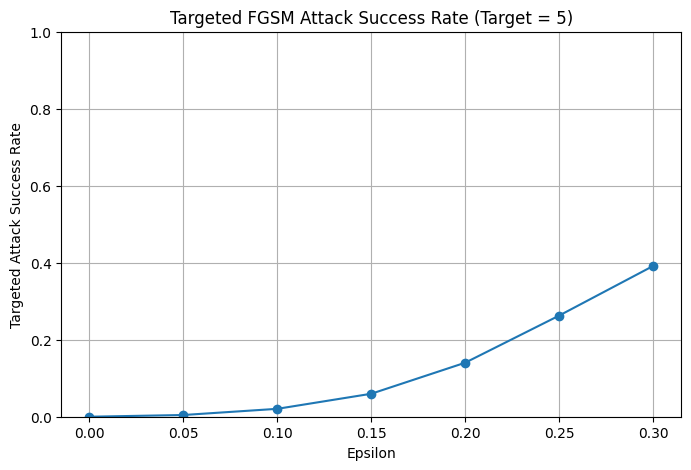

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    epsilons,
    success_rates,
    marker='o'
)

plt.xlabel("Epsilon")
plt.ylabel("Targeted Attack Success Rate")
plt.title("Targeted FGSM Attack Success Rate (Target = 5)")

plt.ylim(0, 1)
plt.grid(True)

plt.savefig(
    "task2_success_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Source digit being attacked toward 5
===========================



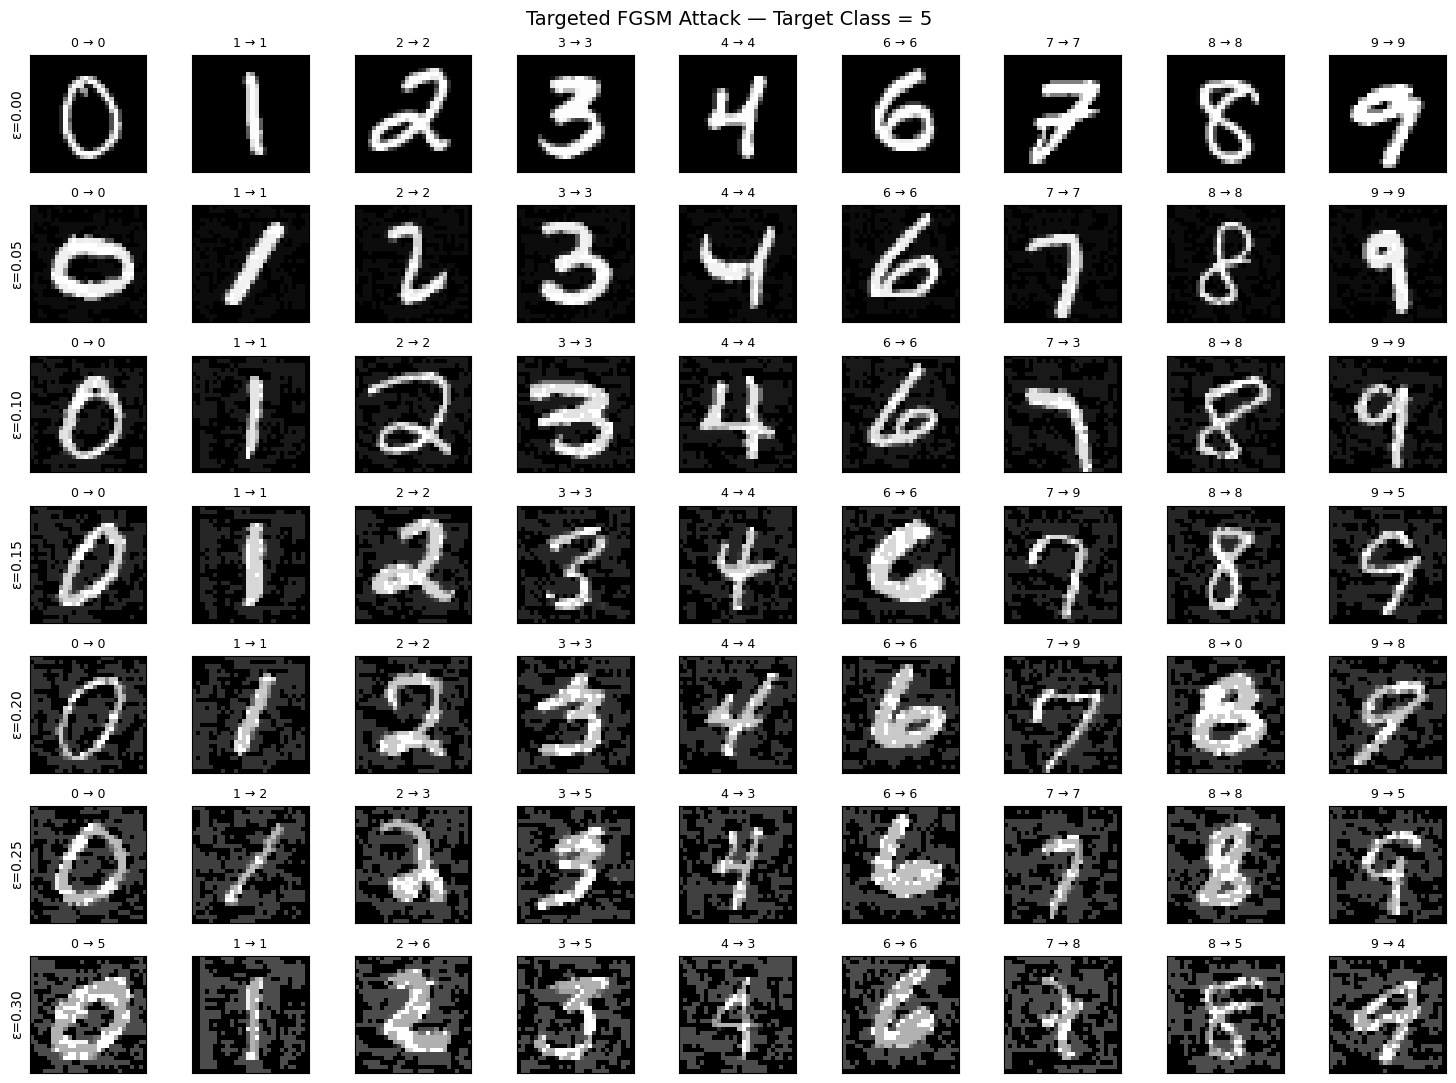

In [24]:
source_classes = [
    0, 1, 2, 3, 4,
    6, 7, 8, 9
]

fig, axes = plt.subplots(
    len(epsilons),
    len(source_classes),
    figsize=(15, 11)
)

for row, epsilon in enumerate(epsilons):

    examples = all_examples[epsilon]

    for col, digit in enumerate(source_classes):

        ax = axes[row, col]

        if digit in examples:

            original, prediction, image, success = examples[digit]

            ax.imshow(
                image,
                cmap="gray"
            )

            ax.set_title(
                f"{original} → {prediction}",
                fontsize=9
            )

        else:

            ax.text(
                0.5,
                0.5,
                "No Sample",
                horizontalalignment="center",
                verticalalignment="center"
            )

        ax.set_xticks([])
        ax.set_yticks([])

        if col == 0:

            ax.set_ylabel(
                f"ε={epsilon:.2f}",
                fontsize=10
            )

plt.suptitle(
    "Targeted FGSM Attack — Target Class = 5",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "task2_targeted_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
def find_successful_targeted_examples(
    model,
    device,
    test_loader,
    epsilon=0.30,
    target_label=5
):

    model.eval()

    source_classes = [0, 1, 2, 3, 4, 6, 7, 8, 9]
    successful_examples = {}

    normalize = transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        true_label = target.item()

        # Skip target class
        if true_label == target_label:
            continue

        # Already found a success for this class
        if true_label in successful_examples:
            continue

        data.requires_grad = True

        # Initial prediction
        output = model(data)
        initial_pred = output.argmax(dim=1)

        # Only attack correctly classified samples
        if initial_pred.item() != true_label:
            continue

        # Target = 5
        target_tensor = torch.full_like(
            target,
            target_label
        )

        loss = F.nll_loss(
            output,
            target_tensor
        )

        model.zero_grad()
        loss.backward()

        data_grad = data.grad.data

        # Restore to pixel scale
        data_denorm = denorm(data)

        # Targeted FGSM
        perturbed_data = targeted_fgsm_attack(
            data_denorm,
            epsilon,
            data_grad
        )

        # Normalize again for model
        perturbed_normalized = normalize(
            perturbed_data
        )

        output = model(
            perturbed_normalized
        )

        final_pred = output.argmax(dim=1).item()

        # Save only successful targeted attacks
        if final_pred == target_label:

            successful_examples[true_label] = (
                perturbed_data
                .squeeze()
                .detach()
                .cpu()
                .numpy()
            )

        # Stop once every class has a successful example
        if len(successful_examples) == len(source_classes):
            break

    return successful_examples

In [26]:
successful_examples = find_successful_targeted_examples(
    model,
    device,
    test_loader,
    epsilon=0.30,
    target_label=5
)

print("Classes with successful targeted examples:")
print(sorted(successful_examples.keys()))

Classes with successful targeted examples:
[0, 1, 2, 3, 4, 6, 7, 8, 9]


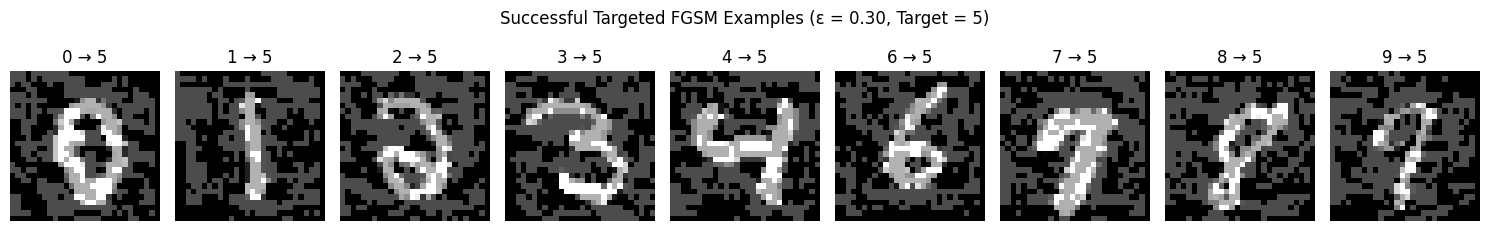

In [27]:
source_classes = [0, 1, 2, 3, 4, 6, 7, 8, 9]

fig, axes = plt.subplots(
    1,
    len(source_classes),
    figsize=(15, 2.5)
)

for ax, digit in zip(axes, source_classes):

    if digit in successful_examples:

        ax.imshow(
            successful_examples[digit],
            cmap="gray"
        )

        ax.set_title(
            f"{digit} → 5"
        )

    else:

        ax.text(
            0.5,
            0.5,
            "No success",
            ha="center",
            va="center"
        )

        ax.set_title(
            f"{digit} → ?"
        )

    ax.axis("off")

plt.suptitle(
    "Successful Targeted FGSM Examples "
    "(ε = 0.30, Target = 5)"
)

plt.tight_layout()

plt.savefig(
    "task2_successful_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()